In [ ]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV,
    cross_val_score,
    learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:

train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nFirst 5 rows of train:")
print(train.head())

print("\nMissing values in train:")
print(train.isnull().sum())

print("\nTrain info:")
print(train.info())



Train shape: (881, 16)
Test shape : (394, 15)

First 5 rows of train:
   id Company      Product   TypeName  Inches  \
0   1   Apple  MacBook Pro  Ultrabook    13.3   
1   2   Apple  Macbook Air  Ultrabook    13.3   
2   3      HP       250 G6   Notebook    15.6   
3   4   Apple  MacBook Pro  Ultrabook    15.4   
4   5   Apple  MacBook Pro  Ultrabook    13.3   

                     ScreenResolution CPU_Company       CPU_Type  \
0  IPS Panel Retina Display 2560x1600       Intel        Core i5   
1                            1440x900       Intel        Core i5   
2                   Full HD 1920x1080       Intel  Core i5 7200U   
3  IPS Panel Retina Display 2880x1800       Intel        Core i7   
4  IPS Panel Retina Display 2560x1600       Intel        Core i5   

   CPU_Frequency (GHz)  RAM (GB)               Memory GPU_Company  \
0                  2.3         8            128GB SSD       Intel   
1                  1.8         8  128GB Flash Storage       Intel   
2                  

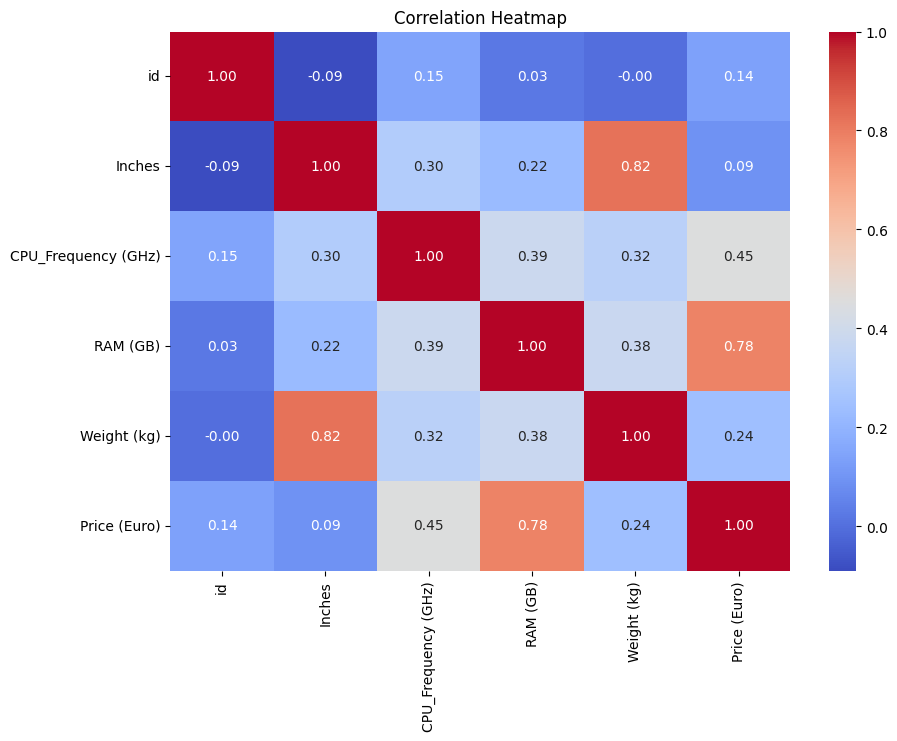

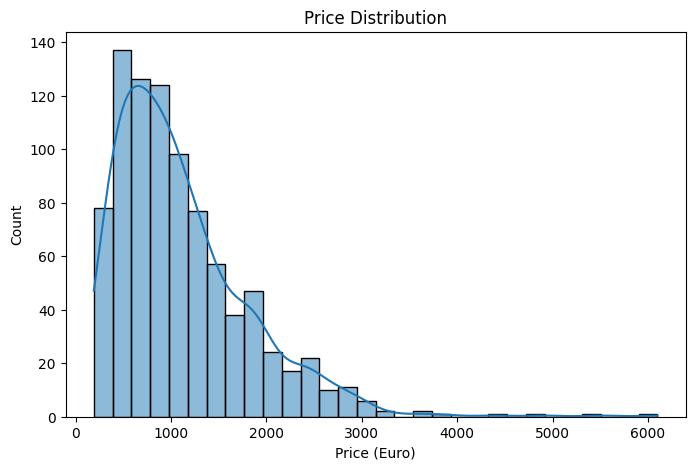

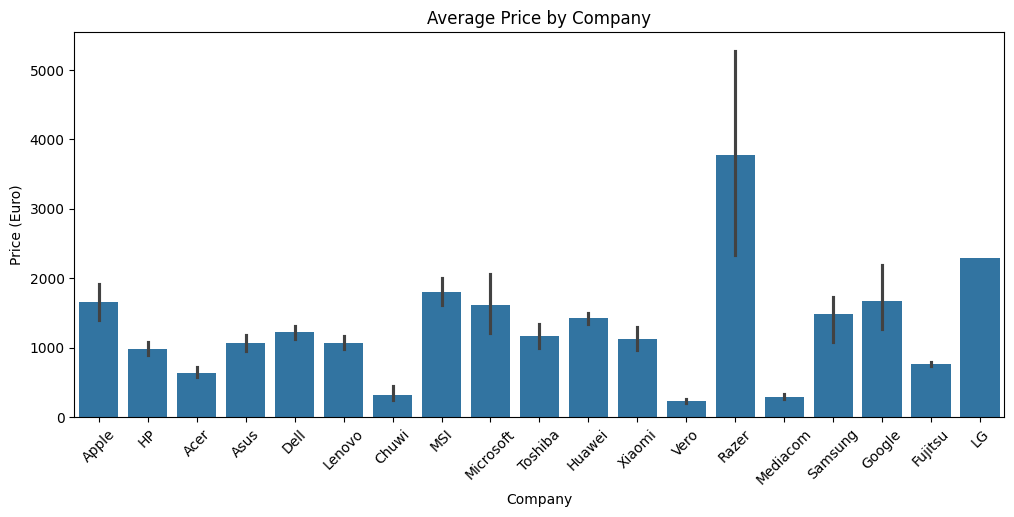

In [ ]:

plt.figure(figsize=(10, 7))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(train["Price (Euro)"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price (Euro)")
plt.ylabel("Count")
plt.show()

if "Company" in train.columns:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=train, x="Company", y="Price (Euro)")
    plt.xticks(rotation=45)
    plt.title("Average Price by Company")
    plt.show()

if "Ram" in train.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=train, x="Ram", y="Price (Euro)")
    plt.title("RAM vs Price")
    plt.show()

if "Weight" in train.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=train, x="Weight", y="Price (Euro)")
    plt.title("Weight vs Price")
    plt.show()



In [ ]:

TARGET = "Price (Euro)"
ID_COL = "id"

X = train.drop(columns=[TARGET]).copy()
y = train[TARGET].copy()

use_log_target = False

if ID_COL in test.columns:
    test_ids = test[ID_COL].copy()
else:
    test_ids = pd.Series(np.arange(len(test)), name="Id")

if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

if ID_COL in test.columns:
    test = test.drop(columns=[ID_COL])

print("\nProcessed X shape:", X.shape)
print("Processed test shape:", test.shape)




Processed X shape: (881, 14)
Processed test shape: (394, 14)


In [ ]:

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("\nCategorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)



Categorical columns: ['Company', 'Product', 'TypeName', 'ScreenResolution', 'CPU_Company', 'CPU_Type', 'Memory', 'GPU_Company', 'GPU_Type', 'OpSys']
Numerical columns: ['Inches', 'CPU_Frequency (GHz)', 'RAM (GB)', 'Weight (kg)']


In [ ]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)



In [ ]:

poly_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

poly_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

poly_preprocessor = ColumnTransformer(
    transformers=[
        ("num", poly_numeric_transformer, numerical_cols),
        ("cat", poly_categorical_transformer, categorical_cols)
    ]
)



In [ ]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_val shape  :", X_val.shape)




X_train shape: (704, 14)
X_val shape  : (177, 14)


In [ ]:

def evaluate_model(name, y_true, y_pred, log_target=False):
    if log_target:
        y_true_real = np.expm1(y_true)
        y_pred_real = np.expm1(y_pred)
    else:
        y_true_real = y_true
        y_pred_real = y_pred

    rmse = np.sqrt(mean_squared_error(y_true_real, y_pred_real))
    mae = mean_absolute_error(y_true_real, y_pred_real)
    r2 = r2_score(y_true_real, y_pred_real)

    print(f"\n{name}")
    print("-" * len(name))
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return {"RMSE": rmse, "MAE": mae, "R2": r2}


In [ ]:

linear_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LinearRegression())
])

poly_model = Pipeline(steps=[
    ("prep", poly_preprocessor),
    ("model", LinearRegression())
])

ridge_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", Ridge())
])

lasso_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", Lasso(alpha=10.0, max_iter=20000))
])

tree_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])



In [ ]:

results = {}

linear_model.fit(X_train, y_train)
pred_linear = linear_model.predict(X_val)
results["Linear Regression"] = evaluate_model(
    "Linear Regression", y_val, pred_linear, log_target=use_log_target
)

poly_model.fit(X_train, y_train)
pred_poly = poly_model.predict(X_val)
results["Polynomial Regression (deg=2)"] = evaluate_model(
    "Polynomial Regression (degree=2)", y_val, pred_poly, log_target=use_log_target
)

ridge_model.fit(X_train, y_train)
pred_ridge = ridge_model.predict(X_val)
results["Ridge Regression"] = evaluate_model(
    "Ridge Regression", y_val, pred_ridge, log_target=use_log_target
)

lasso_model.fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_val)
results["Lasso Regression"] = evaluate_model(
    "Lasso Regression", y_val, pred_lasso, log_target=use_log_target
)

tree_model.fit(X_train, y_train)
pred_tree = tree_model.predict(X_val)
results["Decision Tree"] = evaluate_model(
    "Decision Tree", y_val, pred_tree, log_target=use_log_target
)




Linear Regression
-----------------
RMSE: 361.8211953785012
MAE : 242.49242038640955
R2  : 0.7862955349853338

Polynomial Regression (degree=2)
--------------------------------
RMSE: 381.1866329716728
MAE : 249.8139126027457
R2  : 0.7628075212357852

Ridge Regression
----------------
RMSE: 228.02145050777213
MAE : 165.33903352911338
R2  : 0.9151255455138066

Lasso Regression
----------------
RMSE: 429.90246317913324
MAE : 286.6016679319398
R2  : 0.6983068463073362

Decision Tree
-------------
RMSE: 335.63259232141
MAE : 216.58149717514127
R2  : 0.8161118081198365


In [ ]:

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Linear Regression": linear_model,
    "Polynomial Regression (deg=2)": poly_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Decision Tree": tree_model
}

print("\nK-Fold Cross Validation Results (R2)")
cv_summary = {}

for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring="r2", n_jobs=-1)
    cv_summary[name] = scores.mean()
    print(f"{name}: Mean R2 = {scores.mean():.4f}, Std = {scores.std():.4f}")




K-Fold Cross Validation Results (R2)
Linear Regression: Mean R2 = 0.7610, Std = 0.0480
Polynomial Regression (deg=2): Mean R2 = 0.6832, Std = 0.1014
Ridge Regression: Mean R2 = 0.8872, Std = 0.0196
Lasso Regression: Mean R2 = 0.7192, Std = 0.0108
Decision Tree: Mean R2 = 0.7499, Std = 0.0783


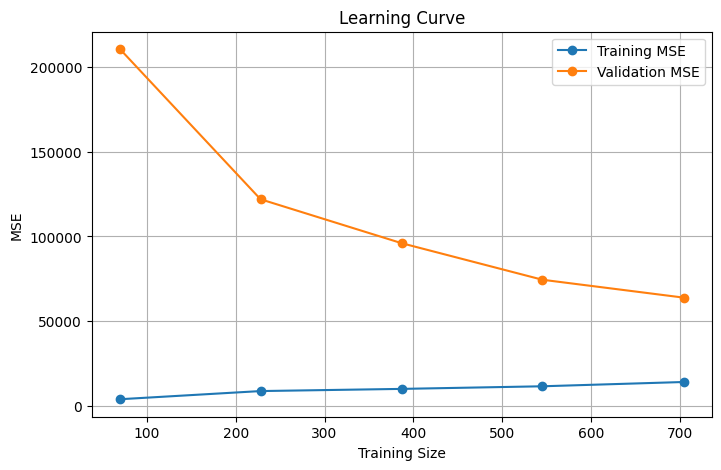

In [ ]:

train_sizes, train_scores, val_scores = learning_curve(
    estimator=ridge_model,
    X=X,
    y=y,
    cv=5,
    scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mse = -train_scores.mean(axis=1)
val_mse = -val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mse, marker="o", label="Training MSE")
plt.plot(train_sizes, val_mse, marker="o", label="Validation MSE")
plt.xlabel("Training Size")
plt.ylabel("MSE")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

ridge_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 5, 10, 50, 100]
}

ridge_grid = GridSearchCV(
    estimator=ridge_model,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

print("\nBest Ridge Params:", ridge_grid.best_params_)
print("Best Ridge CV Score:", ridge_grid.best_score_)

pred_best_ridge = best_ridge.predict(X_val)
ridge_tuned_metrics = evaluate_model(
    "Tuned Ridge Regression", y_val, pred_best_ridge, log_target=use_log_target
)

tree_param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8]
}

tree_grid = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)
best_tree = tree_grid.best_estimator_

print("\nBest Tree Params:", tree_grid.best_params_)
print("Best Tree CV Score:", tree_grid.best_score_)

pred_best_tree = best_tree.predict(X_val)
tree_tuned_metrics = evaluate_model(
    "Tuned Decision Tree", y_val, pred_best_tree, log_target=use_log_target
)




Best Ridge Params: {'model__alpha': 1}
Best Ridge CV Score: 0.8582919401536817

Tuned Ridge Regression
----------------------
RMSE: 228.02145050777213
MAE : 165.33903352911338
R2  : 0.9151255455138066

Best Tree Params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best Tree CV Score: 0.7426273961144607

Tuned Decision Tree
-------------------
RMSE: 339.50769500917346
MAE : 212.19838819388394
R2  : 0.811841071119008



Model Comparison:
                           Model        RMSE         MAE        R2
2               Ridge Regression  228.021451  165.339034  0.915126
5         Tuned Ridge Regression  228.021451  165.339034  0.915126
4                  Decision Tree  335.632592  216.581497  0.816112
6            Tuned Decision Tree  339.507695  212.198388  0.811841
0              Linear Regression  361.821195  242.492420  0.786296
1  Polynomial Regression (deg=2)  381.186633  249.813913  0.762808
3               Lasso Regression  429.902463  286.601668  0.698307


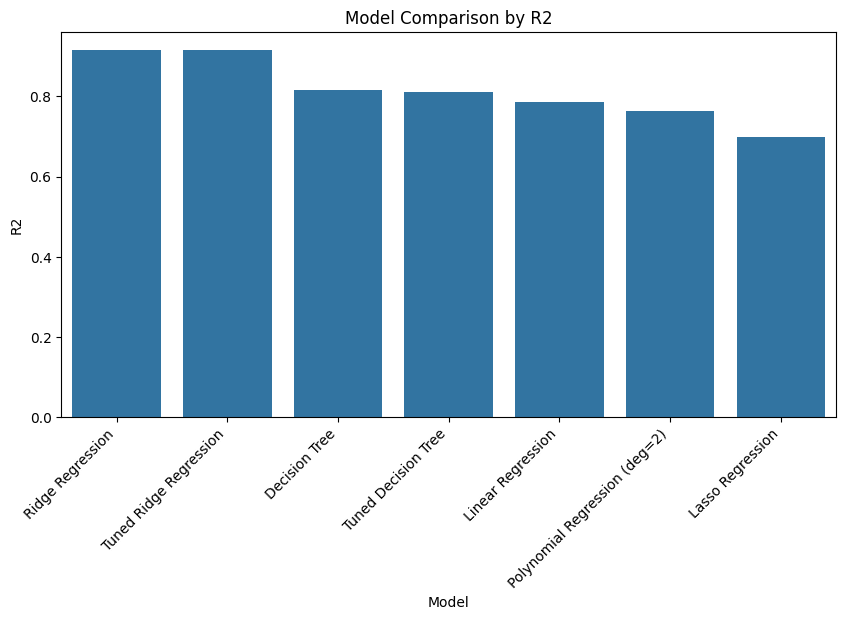

In [ ]:

comparison_rows = []

for model_name, metrics_dict in results.items():
    comparison_rows.append([
        model_name,
        metrics_dict["RMSE"],
        metrics_dict["MAE"],
        metrics_dict["R2"]
    ])

comparison_rows.append([
    "Tuned Ridge Regression",
    ridge_tuned_metrics["RMSE"],
    ridge_tuned_metrics["MAE"],
    ridge_tuned_metrics["R2"]
])

comparison_rows.append([
    "Tuned Decision Tree",
    tree_tuned_metrics["RMSE"],
    tree_tuned_metrics["MAE"],
    tree_tuned_metrics["R2"]
])

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=["Model", "RMSE", "MAE", "R2"]
).sort_values(by="R2", ascending=False)

print("\nModel Comparison:")
print(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="R2")
plt.xticks(rotation=45, ha="right")
plt.title("Model Comparison by R2")
plt.show()



In [ ]:

if ridge_tuned_metrics["R2"] >= tree_tuned_metrics["R2"]:
    final_model = best_ridge
    final_model_name = "Tuned Ridge Regression"
else:
    final_model = best_tree
    final_model_name = "Tuned Decision Tree"

print("\nSelected Final Model:", final_model_name)




Selected Final Model: Tuned Ridge Regression


In [ ]:

final_model.fit(X, y)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Inches',
                                                   'CPU_Frequency (GHz)',
                                                   'RAM (GB)', 'Weight (kg)']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Company', 'Product',
                                                   'TypeName',
                                                   'ScreenResolution',
                                                   'CPU_Company', 'CPU_Type',
                                                   'Memory', 'GPU_Company',
                                                   'GPU_Type', 'OpSys'])])),
                ('model', Ridge(alpha=1))])

In [ ]:

test_predictions = final_model.predict(test)


In [ ]:

submission = pd.DataFrame({
    "id": test_ids,
    "Price": test_predictions
})

submission.to_csv("submission.csv", index=False)
print("\nsubmission.csv created successfully!")




submission.csv created successfully!


In [ ]:

comparison_df.to_csv("model_comparison.csv", index=False)
print("model_comparison.csv created successfully!")

model_comparison.csv created successfully!
